# Modelling HDB Resale Price

In this project we explore the dataset "Resale flat prices based on registration date from Jan-2017 onwards" by HDB. It is an actively-updated dataset.

However, in this analysis I will conduct data exploration, cleaning, preprocessing, and preliminary statistical analysis on a static version obtain on 20 July 2026.

The main aim of this project is to model the resale price of HDBs throughout the years, based on various predictors, and be able to make predictions on HDB resale price based on given variables. As such, as I intend to answer questions like:
- How much should a certain HDB cost?
- How much will a certain HDB appreciate over the years?

In [349]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path

resale_data_path = Path() / "data" / "resale_flat_prices_20260720.csv" # update path as necessary
ResalePrices = pd.read_csv(resale_data_path)

In [350]:
print(ResalePrices.shape)
ResalePrices.head()

(235808, 11)


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


## Data Preparation

### Duplicates and Null Values
There are no null values in the dataset.

There are a number of duplicates in the dataset, making up 0.2% of the data. It is plausible for duplicates to occur because there can be flats on the same block and storey_range and sold for the same price coincidentally, though this should be a rare occurrence.

Since the goal is to predict the resale price, I will drop the duplicates because I believe that it does not make sense to weigh certain values more (due to duplication) because there coincidentally was similar sales at the exact same time.

In [351]:
# check for null values
ResalePrices.loc[ResalePrices.isna().any(axis=1)]

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price


In [352]:
# check for duplicates
duplicates = ResalePrices.loc[ResalePrices.duplicated(keep=False)]
print(duplicates.shape[0] / ResalePrices.shape[0] * 100) # % of the dataset that is duplicates
# drop the duplicates, re-number the index
ResalePrices = ResalePrices.drop_duplicates(keep='first')
# see which values are duplicates
duplicates

0.2675905821685439


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
224,2017-01,BUKIT MERAH,4 ROOM,106,HENDERSON CRES,07 TO 09,81.0,Improved,1975,57 years,470000.0
243,2017-01,BUKIT MERAH,4 ROOM,106,HENDERSON CRES,07 TO 09,81.0,Improved,1975,57 years,470000.0
304,2017-01,CENTRAL AREA,3 ROOM,271,QUEEN ST,16 TO 18,68.0,Improved,1979,61 years 02 months,470000.0
305,2017-01,CENTRAL AREA,3 ROOM,271,QUEEN ST,16 TO 18,68.0,Improved,1979,61 years 02 months,470000.0
505,2017-01,JURONG EAST,4 ROOM,265,TOH GUAN RD,04 TO 06,101.0,Model A,1998,80 years 09 months,470000.0
...,...,...,...,...,...,...,...,...,...,...,...
231833,2026-03,SENGKANG,5 ROOM,224C,COMPASSVALE WALK,07 TO 09,121.0,Improved,1999,72 years 01 month,680000.0
233624,2026-03,TOA PAYOH,4 ROOM,103B,BIDADARI PK DR,07 TO 09,93.0,Model A,2021,94 years 04 months,1095000.0
233627,2026-03,TOA PAYOH,4 ROOM,103B,BIDADARI PK DR,07 TO 09,93.0,Model A,2021,94 years 04 months,1095000.0
233992,2026-04,WOODLANDS,3 ROOM,148,WOODLANDS ST 13,01 TO 03,68.0,New Generation,1985,57 years 11 months,385000.0


### Train-Test Split
For doing a temporal train-test split, I will need to convert the `month` string values into datetime values, and split accordingly.

In [353]:
# convert "month" to datetime datatype
ResalePrices['date'] = pd.to_datetime(ResalePrices['month'], format="%Y-%m", errors="coerce")
# drop any rows with an invalid date
print(f"Number of rows with date errors: {ResalePrices['date'].isna().sum()}")
ResalePrices = ResalePrices[~ResalePrices['date'].isna()]
# sort rows according to date, and re-number the index
ResalePrices = ResalePrices.sort_values(by="date").reset_index(drop=True)

Number of rows with date errors: 0


In [354]:
# train-test split
cutoff_date = ResalePrices.iloc[int(ResalePrices.shape[0] * 0.8)]['date']
print(f"Cutoff Date: {cutoff_date} - This is the last date in the training dataset.")
ResalePrices_Train = ResalePrices[ResalePrices['date'] <= cutoff_date]
ResalePrices_Test = ResalePrices[ResalePrices['date'] > cutoff_date]
print(f"ResalePrices_Train: {ResalePrices_Train.shape}")
print(f"ResalePrices_Test: {ResalePrices_Test.shape}")

print(f"Final split: [Train] {ResalePrices_Train.shape[0] / ResalePrices.shape[0]:.2f} / [Test] {ResalePrices_Test.shape[0] / ResalePrices.shape[0]:.2f} ")

Cutoff Date: 2024-09-01 00:00:00 - This is the last date in the training dataset.
ResalePrices_Train: (190510, 12)
ResalePrices_Test: (44982, 12)
Final split: [Train] 0.81 / [Test] 0.19 


In [355]:
ResalePrices_Train.iloc[-5:]

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,date
190505,2024-09,KALLANG/WHAMPOA,3 ROOM,685,RACE COURSE RD,01 TO 03,63.0,Simplified,1986,60 years 05 months,450000.0,2024-09-01
190506,2024-09,KALLANG/WHAMPOA,3 ROOM,30,BENDEMEER RD,07 TO 09,68.0,Improved,1972,46 years 05 months,450000.0,2024-09-01
190507,2024-09,KALLANG/WHAMPOA,3 ROOM,12,UPP BOON KENG RD,07 TO 09,66.0,Improved,1980,55 years 02 months,460000.0,2024-09-01
190508,2024-09,KALLANG/WHAMPOA,3 ROOM,685,RACE COURSE RD,07 TO 09,63.0,Simplified,1986,60 years 05 months,470000.0,2024-09-01
190509,2024-09,KALLANG/WHAMPOA,4 ROOM,99,WHAMPOA DR,04 TO 06,91.0,Improved,1974,48 years 07 months,476000.0,2024-09-01


In [356]:
ResalePrices_Test[:5]

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,date
190510,2024-10,WOODLANDS,3 ROOM,204,MARSILING DR,10 TO 12,68.0,New Generation,1981,55 years 07 months,370000.0,2024-10-01
190511,2024-10,WOODLANDS,4 ROOM,8,MARSILING DR,04 TO 06,88.0,Improved,1976,50 years 04 months,368000.0,2024-10-01
190512,2024-10,WOODLANDS,3 ROOM,6,MARSILING DR,13 TO 15,76.0,Improved,1976,50 years 04 months,362888.0,2024-10-01
190513,2024-10,WOODLANDS,3 ROOM,130,MARSILING RISE,10 TO 12,60.0,Improved,1985,59 years 04 months,358000.0,2024-10-01
190514,2024-10,WOODLANDS,3 ROOM,13,MARSILING LANE,10 TO 12,65.0,Improved,1976,50 years 06 months,355000.0,2024-10-01


### Examining Nominal Categorical Variables
We have 3 variables given in the dataset that may have a relationship with the resale price - `town`, `flat_type`, and `flat_model`.

Without doing any processing, I examine their values here with `value_counts()` and hypothesize if there is any relationship between these variables and the resale price.

For `town`, it is likely that certain towns are more desirable than others due to the amenities present in the town, such as "good" schools, parks, connectivity (especially in the central area).
- I will handle this variable with one-hot encoding.

For `flat_type`, it is a variable that is correlated with `floor_area_sqm`. However there are certain properties that cannot be represented by `floor_area_sqm`, such as the increased number of toilets and master bedrooms in "multi-generation" flats, which can possibly affect the desirability and hence resale price of a flat.
- I will also handle this variable with one-hot encoding.

For `flat_model`, it is a variable that mostly indicates the layout of the flats. Since layouts are constantly changing over the years (started/discontinued), it may be correlated with `remaining_lease_months`. It may also be correlated with `floor_area_sqm` since some layouts obviously take up more space than others. There are many unique values for this category and over half of them do not have a lot of samples, so it may be difficult to draw conclusions with this variable. Perhaps more research can be done to group up similar categories.
- For now, I will exclude this predictor because I currently have no good way of dealing with it. I believe that naively one-hot encoding it will lead to erroneous results if not careful because of the large number of categories and small sample sizes for a lot of the categories.



In [357]:
# helper functions for plotting boxplots for resale_price & floor_area_sqm

def plot_resale_price(df, by, figsize=(16,5)):
    fig, ax = plt.subplots(figsize=figsize)
    df.boxplot(column="resale_price", by=by, ax=ax, rot=20)
    ax.axhline(y=ResalePrices['resale_price'].mean(), c="b", ls="--", label="mean resale price")
    ax.legend(loc="upper right")
    plt.tight_layout()

def plot_floor_area_sqm(df, by, figsize=(16,5)):
    fig, ax = plt.subplots(figsize=figsize)
    ResalePrices.boxplot(column="floor_area_sqm", by=by, ax=ax, rot=20)
    ax.axhline(y=ResalePrices['floor_area_sqm'].mean(), c="b", ls="--", label="mean floor area sqm")
    ax.legend(loc="upper right")
    plt.tight_layout()

#### `town` Value Counts & Boxplots

In [358]:
# town
value_counts = ResalePrices['town'].value_counts()
df = pd.DataFrame({
    "value counts": value_counts,
    "fraction": value_counts / value_counts.sum()
}, index=value_counts.index)
df

,value counts,fraction
town,,
SENGKANG,19093,0.081077
PUNGGOL,17017,0.072261
WOODLANDS,16790,0.071298
TAMPINES,16247,0.068992
YISHUN,15989,0.067896
JURONG WEST,15470,0.065692
BEDOK,12234,0.051951
HOUGANG,11887,0.050477
CHOA CHU KANG,10596,0.044995


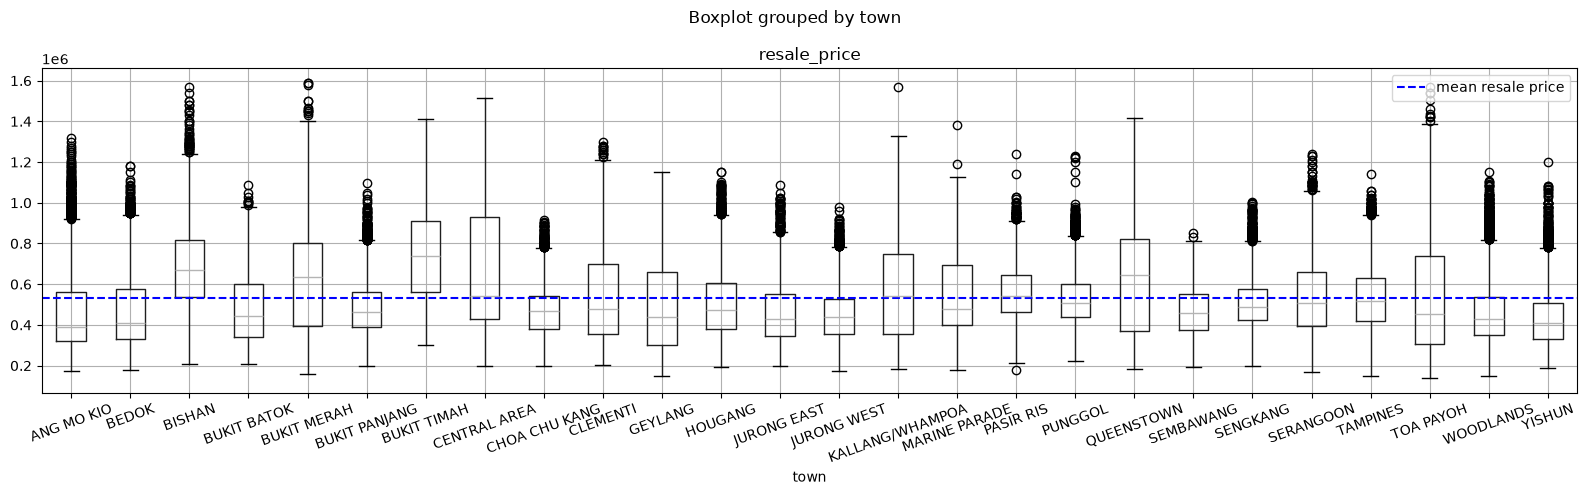

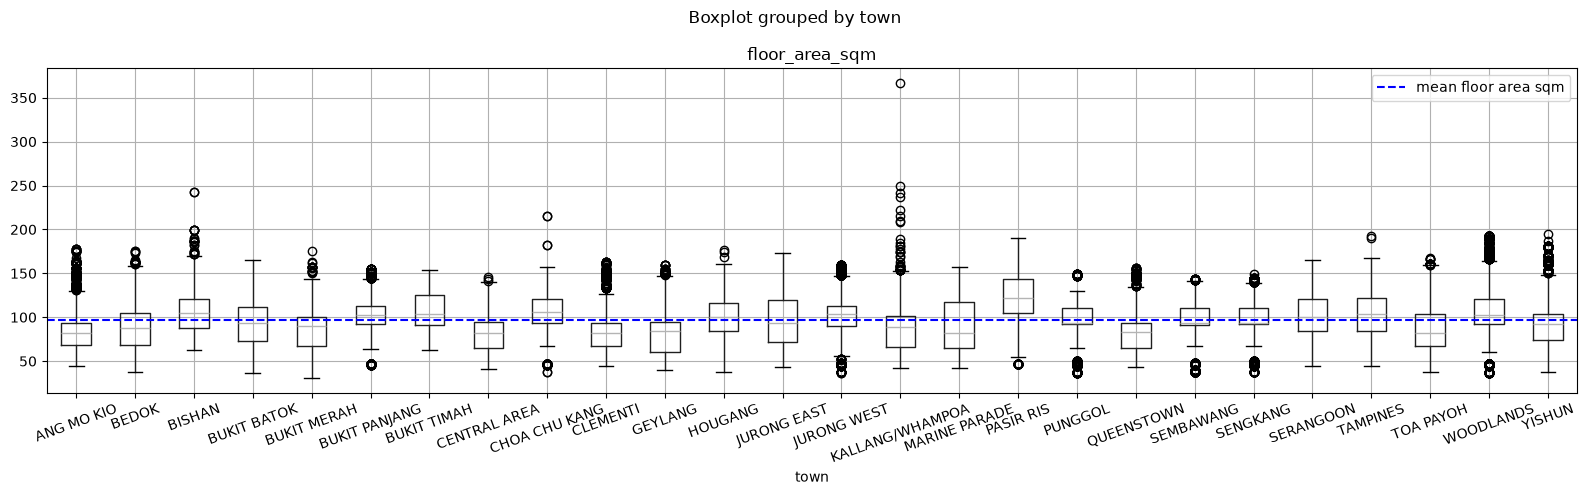

In [359]:
plot_resale_price(ResalePrices_Train, by="town")
plot_floor_area_sqm(ResalePrices_Train, by="town")

#### `flat_type` Value Counts and Boxplots

In [360]:
# flat_type
value_counts = ResalePrices['flat_type'].value_counts()
df = pd.DataFrame({
    "value counts": value_counts,
    "fraction": value_counts / value_counts.sum()
}, index=value_counts.index)
df

,value counts,fraction
flat_type,,
4 ROOM,99960,0.424473
5 ROOM,57605,0.244616
3 ROOM,56075,0.238118
EXECUTIVE,16762,0.071179
2 ROOM,4916,0.020875
MULTI-GENERATION,88,0.000374
1 ROOM,86,0.000365


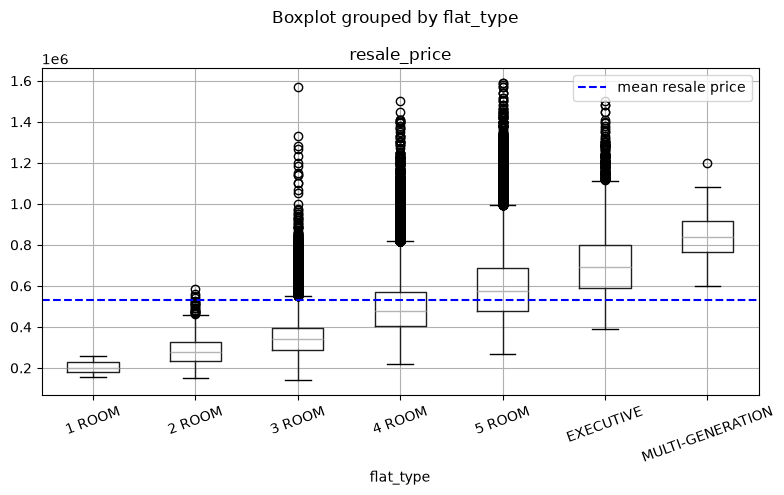

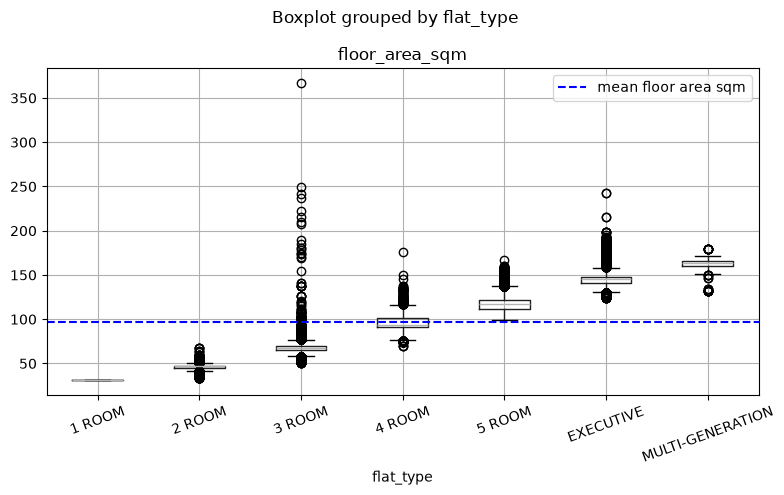

In [361]:
plot_resale_price(ResalePrices_Train, by="flat_type", figsize=(8,5))
plot_floor_area_sqm(ResalePrices_Train, by="flat_type", figsize=(8,5))

#### `flat_model` Value Counts and Boxplots

In [362]:
# flat_model
value_counts = ResalePrices['flat_model'].value_counts()
df = pd.DataFrame({
    "value counts": value_counts,
    "fraction": value_counts / value_counts.sum()
}, index=value_counts.index)
df

,value counts,fraction
flat_model,,
Model A,84721,0.359762
Improved,57474,0.244059
New Generation,28647,0.121647
Premium Apartment,25804,0.109575
Simplified,9004,0.038235
Apartment,8417,0.035742
Maisonette,6420,0.027262
Standard,6267,0.026612
DBSS,3755,0.015945


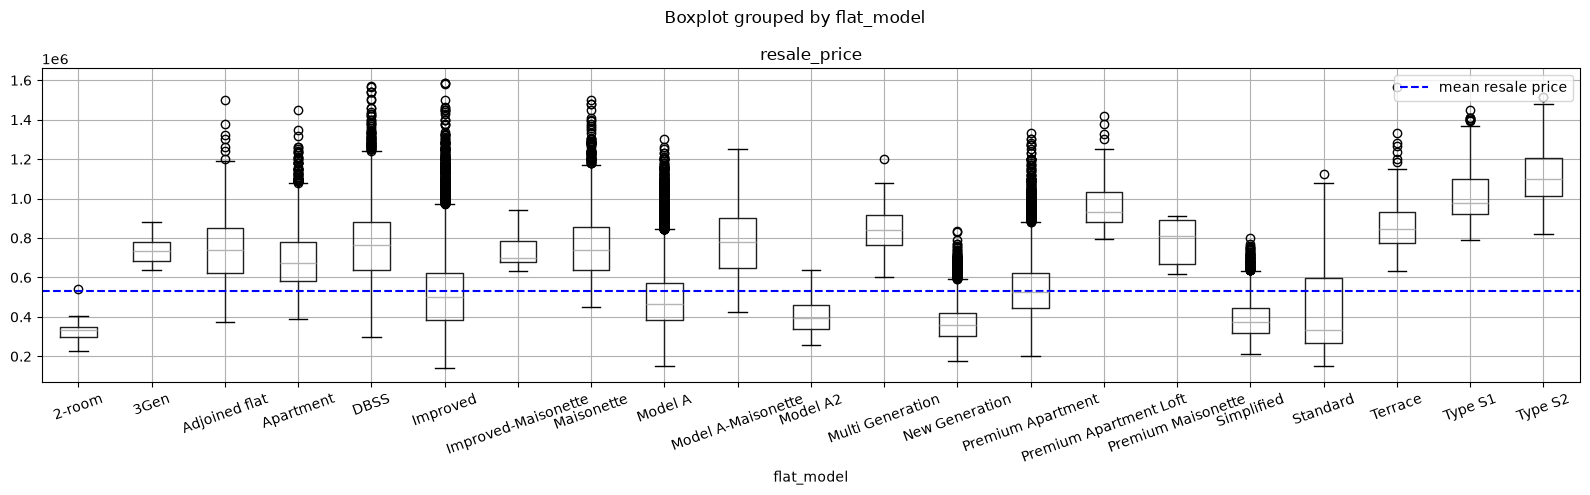

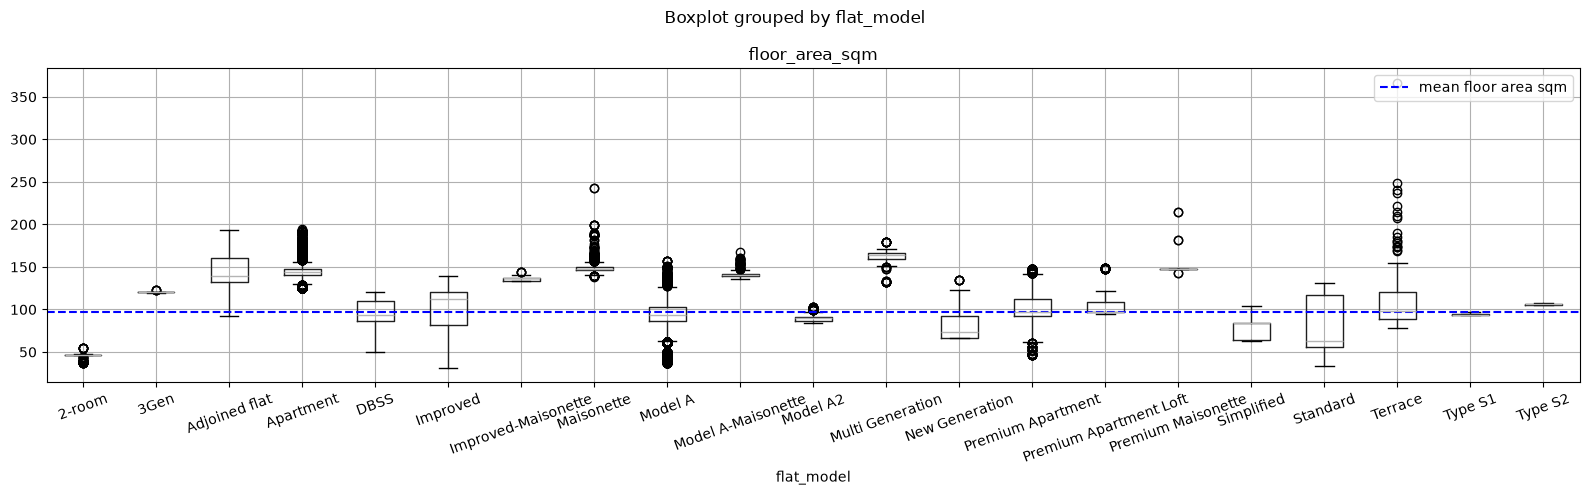

In [363]:
plot_resale_price(ResalePrices_Train, by="flat_model")
plot_floor_area_sqm(ResalePrices_Train, by="flat_model")

### Transforming Data Types
Most of the columns are in string format, but actually contain date, numerical, or ordinal data. They are transformed accordingly.

In [364]:
def transform_data(df, min_date):
    # create new quantitative variable "regdate_months" counting number of months since minimum date for the registration date of the sale.
    # - note that "months" vary from 28 days to 31 days but since the data is recorded in months I decided to keep the same format.
    # - this value is 0 for the first month in the dataset
    # - we expect the resale price to go up with this number due to external economic factors like inflation.
    df["regdate_months"] = (df['date'].dt.year * 12 + df['date'].dt.month) - (min_date.year * 12 + min_date.month)

    # convert "storey_range" to ordinal categorical variable, by dividing the storey number by 3
    df['storey_range_cat'] = df['storey_range'].str.split(" TO ").str[1].astype(int) // 3

    # convert "remaining_lease" to a quantitative variable by parsing its string value
    ym = df['remaining_lease'].str.extract(r"(?:(\d+) years?)?\s?(?:(\d+) months?)?").fillna(0) # extract years and months from the string (can be null), fill nulls to 0
    df['remaining_lease_months'] = ym.loc[:, 0].astype(int) * 12 + ym.loc[:, 1].astype(int) # num years * 12 + num months

    return df

In [365]:
# find minimum date
MIN_DATE = ResalePrices['date'].min()

ResalePrices_Train = transform_data(ResalePrices_Train, MIN_DATE)
ResalePrices_Test = transform_data(ResalePrices_Test, MIN_DATE)

ResalePrices_Train.head(2)

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,date,regdate_months,storey_range_cat,remaining_lease_months
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0,2017-01-01,0,4,736
1,2017-01,SEMBAWANG,4 ROOM,335,SEMBAWANG CL,01 TO 03,100.0,Model A,1999,81 years 09 months,342000.0,2017-01-01,0,1,981


### Feature Selection
The predictors involved are namely:

Continuous variables:
- `regdate_months`: number of months since minimum registration date; a measure of how recent the transaction was.
- `storey_range_cat`: an ordinal continuous variable representing the storey range of the flat
- `floor_area_sqm`: number of square metres of the flat's floor area
- `remaining_lease_months`: number of months until the lease of the flat ends

One-hot encoded, categorical variables:
- `town`: town of the involved flat, e.g. "Bishan", "Yishun", etc.
- `flat_type`: type of flat, e.g. "2 room", "4 room", etc.
- `flat_model`: model of flat as described by HDB. It is difficult to give a precise description of the differences between each model, but basically it represents the layout of the flat.

In [366]:
def select_features_and_add_intercept(df, columns=['regdate_months', 'storey_range_cat', 'floor_area_sqm', 'remaining_lease_months', 'town', 'flat_type', 'flat_model']):
    CONTINUOUS_VARIABLES = ['regdate_months', 'storey_range_cat', 'floor_area_sqm', 'remaining_lease_months']
    DISCRETE_VARIABLES = ['town', 'flat_type', 'flat_model']

    continuous = list(filter(lambda s: s in CONTINUOUS_VARIABLES, columns))
    to_ohe = list(filter(lambda s: s in DISCRETE_VARIABLES, columns))

    if (not continuous) and (not to_ohe):
        raise ValueError("Invalid columns provided!")

    if not to_ohe:
        X = df[continuous]
    elif not continuous:
        X = pd.get_dummies(df[to_ohe], columns=to_ohe, drop_first=True, dtype=int)
    else:
        ohe = pd.get_dummies(df[to_ohe], columns=to_ohe, drop_first=True, dtype=int)
        X = pd.concat([df[continuous], ohe], axis=1)
    
    # add intercept
    X = sm.add_constant(X)

    return X

def select_features_and_add_intercept_polynomial(df, columns=['regdate_months', 'storey_range_cat', 'floor_area_sqm', 'remaining_lease_months']):
    X = pd.DataFrame()
    
    # add feature with polynomial terms
    for col in columns:
        X[col] = df[col]
        X[f"{col}^2"] = np.pow(df[col], 2)
        X[f"{col}^3"] = np.pow(df[col], 3)
    
    # add intercept
    X = sm.add_constant(X)

    return X

def get_target(df):
    return df['resale_price']

### Preliminary Modelling with OLS Linear Regression
I intend to build up my fundamentals in linear regression, so I will be selecting features for linear regression. It is possible to explore other types of models in the future, but for this project I would like to focus on linear regression first.

I will look at trends and t-statistics / F-statistics to determine associations between predictors and response in:
1. univariate linear regression (i.e. only 1 predictor variable)
2. univariate polynomial regression (1 predictor variable, but with polynomial terms, (X^2 and X^3) added)
3. multiple linear regression with **all** predictor variables.
4. multiple linear regression with **selected** predictor variables.

In [373]:
def plot_residual_fittedvalue(result, title=None, ax=None):
    if not ax:
        fig, ax = plt.subplots(figsize=(6,6))
    ax.scatter(result.fittedvalues, result.resid)
    ax.axhline(y=0, c='b', ls='--', label="residual = 0")
    ax.set_ylabel("residual")
    ax.set_xlabel("fitted values")
    if title is not None:
        ax.set_title(title)
    ax.legend()
    plt.tight_layout()

In [368]:
y_train = get_target(ResalePrices_Train)

#### Univariate Simple Linear Regression

Univariate Simple Linear Regression with predictor regdate_months
                            OLS Regression Results                            
Dep. Variable:           resale_price   R-squared:                       0.113
Model:                            OLS   Adj. R-squared:                  0.113
Method:                 Least Squares   F-statistic:                 2.418e+04
Date:                Wed, 22 Jul 2026   Prob (F-statistic):               0.00
Time:                        17:27:53   Log-Likelihood:            -2.5598e+06
No. Observations:              190510   AIC:                         5.120e+06
Df Residuals:                  190508   BIC:                         5.120e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

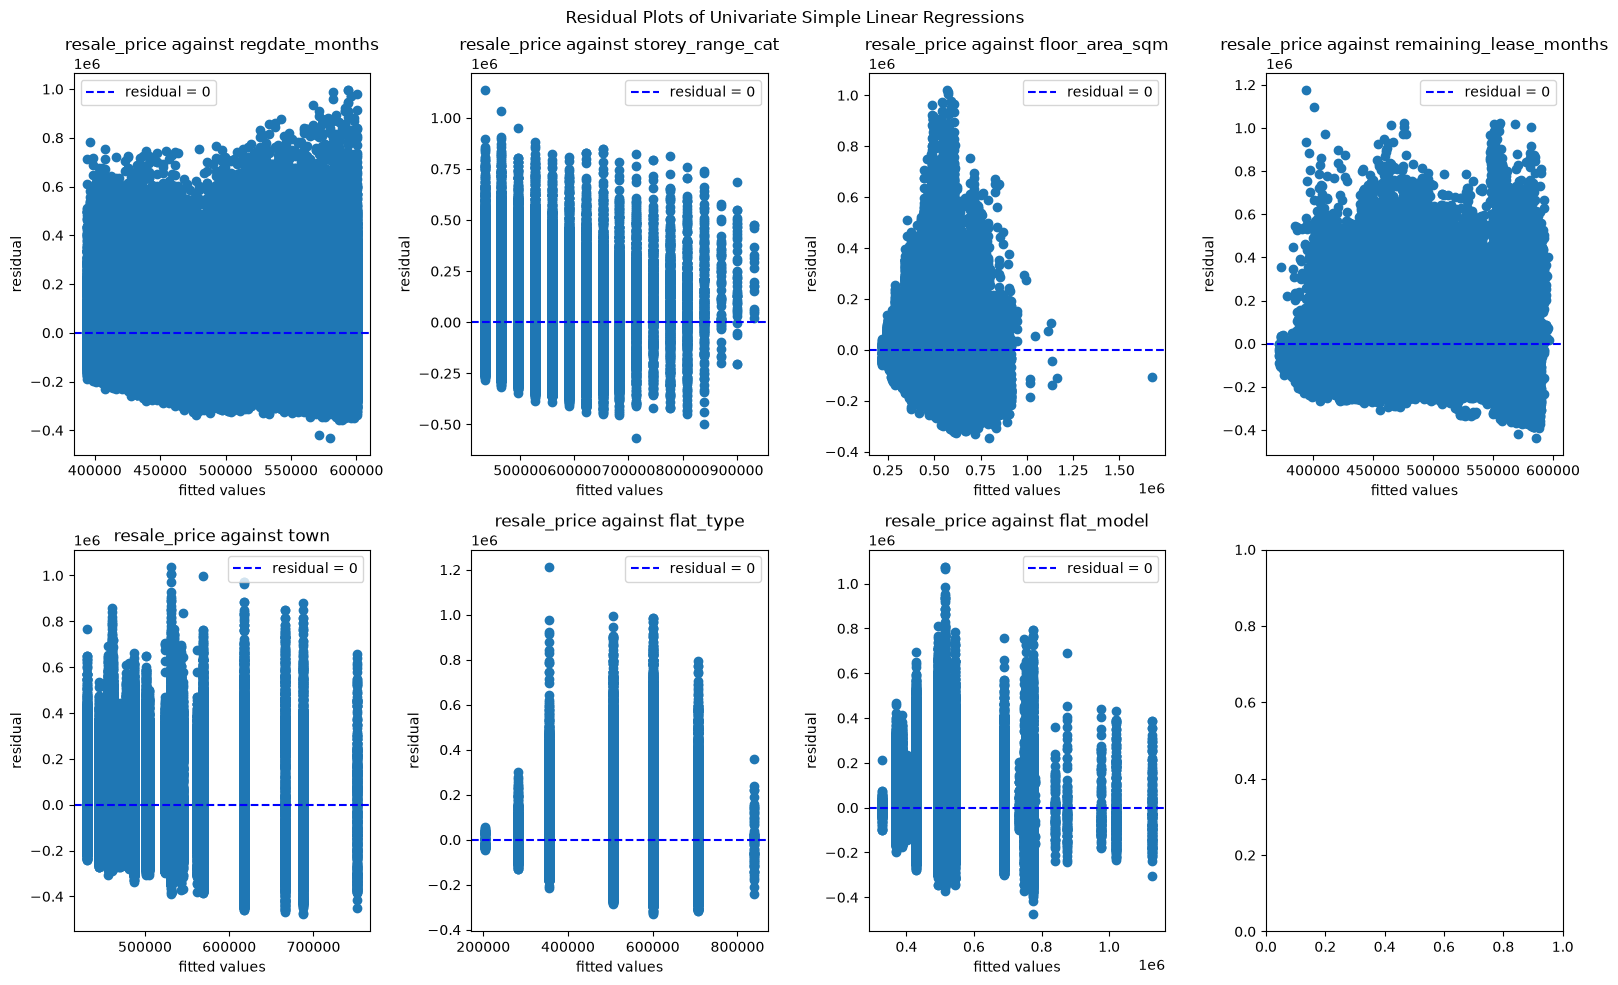

In [376]:
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(16, 10))
fig.suptitle("Residual Plots of Univariate Simple Linear Regressions")
for idx, col in enumerate(['regdate_months', 'storey_range_cat', 'floor_area_sqm', 'remaining_lease_months', 'town', 'flat_type', 'flat_model']):
    X_train = select_features_and_add_intercept(ResalePrices_Train, columns=[col])
    result = sm.OLS(y_train, X_train).fit()
    print(f"Univariate Simple Linear Regression with predictor {col}")
    print(result.summary())
    print("---")
    i = idx // 4
    j = idx % 4
    plot_residual_fittedvalue(result, title=f"resale_price against {col}", ax=axs[i][j])

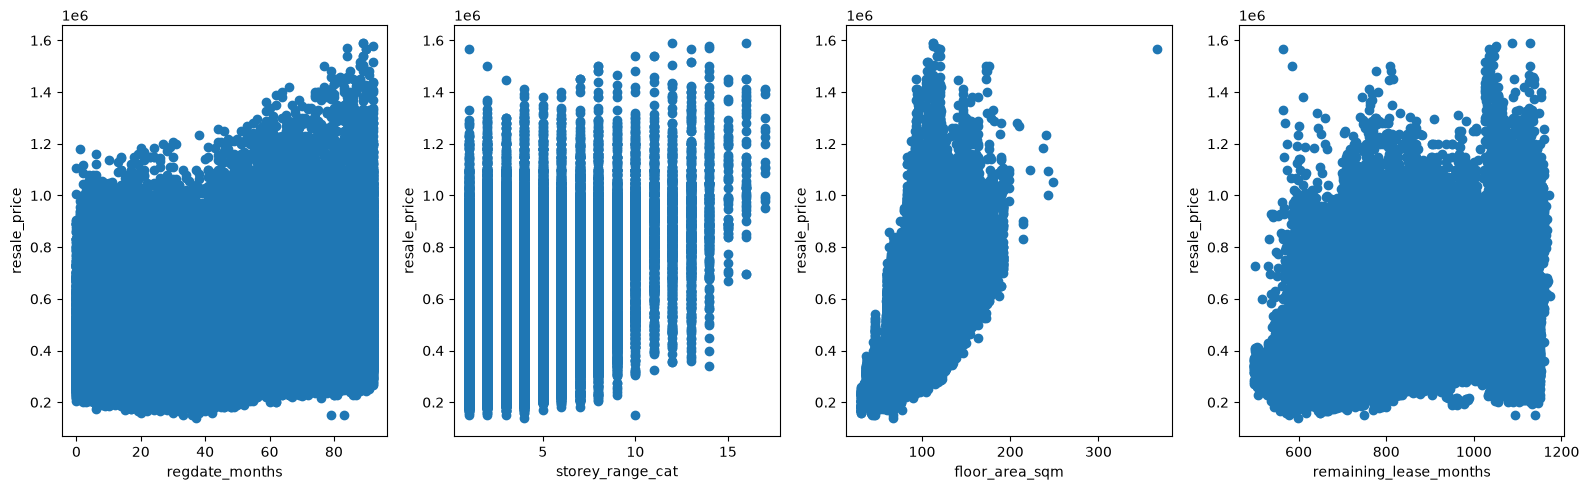

In [370]:
fig, axs = plt.subplots(ncols=4, figsize=(16, 5))
for i, col in enumerate(['regdate_months', 'storey_range_cat', 'floor_area_sqm', 'remaining_lease_months']):
    axs[i].scatter(ResalePrices_Train[col], ResalePrices_Train['resale_price'])
    axs[i].set_ylabel("resale_price")
    axs[i].set_xlabel(col)
plt.tight_layout()

#### Univariate Polynomial Linear Regression


In [371]:
for col in ['regdate_months', 'storey_range_cat', 'floor_area_sqm', 'remaining_lease_months']:
    X_train = select_features_and_add_intercept_polynomial(ResalePrices_Train, columns=[col])
    result = sm.OLS(y_train, X_train).fit()
    print(f"Univariate Polynomial Linear Regression with predictor {col}")
    print(result.summary())
    print("---")

Univariate Polynomial Linear Regression with predictor regdate_months
                            OLS Regression Results                            
Dep. Variable:           resale_price   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.125
Method:                 Least Squares   F-statistic:                     9088.
Date:                Wed, 22 Jul 2026   Prob (F-statistic):               0.00
Time:                        17:22:11   Log-Likelihood:            -2.5584e+06
No. Observations:              190510   AIC:                         5.117e+06
Df Residuals:                  190506   BIC:                         5.117e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------

#### Multiple Linear Regression with **all** predictor variables

In [377]:
X_train = select_features_and_add_intercept(ResalePrices_Train) # select all columns
result = sm.OLS(y_train, X_train).fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           resale_price   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.863
Method:                 Least Squares   F-statistic:                 2.223e+04
Date:                Wed, 22 Jul 2026   Prob (F-statistic):               0.00
Time:                        17:33:38   Log-Likelihood:            -2.3818e+06
No. Observations:              190510   AIC:                         4.764e+06
Df Residuals:                  190455   BIC:                         4.764e+06
Df Model:                          54                                         
Covariance Type:            nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                             -4.654e+05   9961.760    -46.714      0.000   -4.85e+05   -4.46e+05
regdate_months                     2549.9642      5.747    443.678      0.000    2538.700    2561.229
storey_range_cat                   1.448e+04     84.503    171.346      0.000    1.43e+04    1.46e+04
floor_area_sqm                     4148.8492     28.532    145.409      0.000    4092.927    4204.772
remaining_lease_months              422.2233      1.572    268.572      0.000     419.142     425.305
town_BEDOK                        -1.769e+04    994.974    -17.779      0.000   -1.96e+04   -1.57e+04
town_BISHAN                        9.649e+04   1393.609     69.235      0.000    9.38e+04    9.92e+04
town_BUKIT BATOK                  -8.781e+04   1090.460    -80.527      0.000   -8.99e+04   -8.57e+04
town_BUKIT MERAH                   1.072e+05   1120.753     95.664      0.000    1.05e+05    1.09e+05
town_BUKIT PANJANG                -1.371e+05   1147.901   -119.426      0.000   -1.39e+05   -1.35e+05
town_BUKIT TIMAH                   2.004e+05   3097.862     64.705      0.000    1.94e+05    2.07e+05
town_CENTRAL AREA                  1.038e+05   2199.102     47.209      0.000    9.95e+04    1.08e+05
town_CHOA CHU KANG                -1.723e+05   1089.715   -158.136      0.000   -1.74e+05    -1.7e+05
town_CLEMENTI                      2.623e+04   1242.549     21.111      0.000    2.38e+04    2.87e+04
town_GEYLANG                        4.21e+04   1263.697     33.318      0.000    3.96e+04    4.46e+04
town_HOUGANG                      -8.247e+04   1041.149    -79.213      0.000   -8.45e+04   -8.04e+04
town_JURONG EAST                  -8.131e+04   1292.430    -62.915      0.000   -8.38e+04   -7.88e+04
town_JURONG WEST                  -1.366e+05   1006.812   -135.725      0.000   -1.39e+05   -1.35e+05
town_KALLANG/WHAMPOA                6.24e+04   1186.044     52.608      0.000    6.01e+04    6.47e+04
town_MARINE PARADE                 1.408e+05   2116.845     66.520      0.000    1.37e+05    1.45e+05
town_PASIR RIS                     -1.02e+05   1220.719    -83.535      0.000   -1.04e+05   -9.96e+04
town_PUNGGOL                      -1.286e+05   1059.084   -121.443      0.000   -1.31e+05   -1.27e+05
town_QUEENSTOWN                    1.111e+05   1248.535     89.005      0.000    1.09e+05    1.14e+05
town_SEMBAWANG                    -1.705e+05   1247.484   -136.664      0.000   -1.73e+05   -1.68e+05
town_SENGKANG                     -1.443e+05   1015.350   -142.159      0.000   -1.46e+05   -1.42e+05
town_SERANGOON                     2072.9662   1365.486      1.518      0.129    -603.354    4749.286
town_TAMPINES                     -4.828e+04   1005.655    -48.005      0.000   -5.02e+04   -4.63e+04
town_TOA PAYOH         

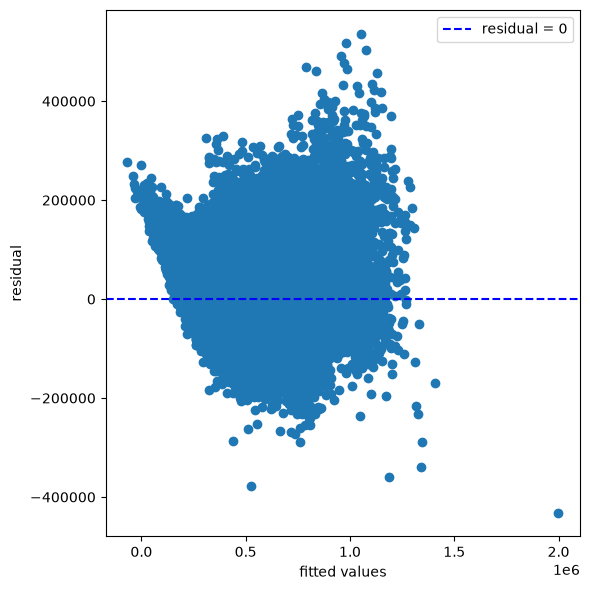

In [378]:
plot_residual_fittedvalue(result)

In [383]:
# find fitted values < 0
# find fitted values > 1.5 million

ResalePrices_Train[result.fittedvalues < 0]

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,date,regdate_months,storey_range_cat,remaining_lease_months
537,2017-01,WOODLANDS,3 ROOM,1,MARSILING DR,01 TO 03,65.0,Improved,1974,56 years 06 months,270000.0,2017-01-01,0,1,678
2001,2017-02,JURONG WEST,2 ROOM,191,BOON LAY DR,07 TO 09,37.0,Model A,1978,60 years 06 months,210000.0,2017-02-01,1,3,726
5528,2017-04,JURONG WEST,2 ROOM,191,BOON LAY DR,04 TO 06,48.0,Model A,1978,60 years 03 months,200000.0,2017-04-01,3,2,723
10482,2017-07,WOODLANDS,2 ROOM,16,MARSILING LANE,07 TO 09,45.0,Improved,1984,66 years 04 months,188000.0,2017-07-01,6,3,796
12984,2017-08,JURONG WEST,2 ROOM,191,BOON LAY DR,01 TO 03,48.0,Model A,1978,60 years,210000.0,2017-08-01,7,1,720
18382,2017-11,JURONG WEST,2 ROOM,191,BOON LAY DR,07 TO 09,44.0,Model A,1978,59 years 08 months,200000.0,2017-11-01,10,3,716
18383,2017-11,JURONG WEST,2 ROOM,191,BOON LAY DR,07 TO 09,44.0,Model A,1978,59 years 08 months,198000.0,2017-11-01,10,3,716
21958,2018-02,WOODLANDS,2 ROOM,16,MARSILING LANE,07 TO 09,45.0,Improved,1984,65 years 10 months,200000.0,2018-02-01,13,3,790
22341,2018-02,JURONG WEST,2 ROOM,191,BOON LAY DR,01 TO 03,47.0,Model A,1978,59 years 05 months,195000.0,2018-02-01,13,1,713
29533,2018-06,JURONG WEST,2 ROOM,112,HO CHING RD,01 TO 03,56.0,Improved,1970,51 years 03 months,175000.0,2018-06-01,17,1,615


In [384]:
ResalePrices_Train[result.fittedvalues > 1500000]

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,date,regdate_months,storey_range_cat,remaining_lease_months
185021,2024-07,KALLANG/WHAMPOA,3 ROOM,53,JLN MA'MOR,01 TO 03,366.7,Terrace,1972,47 years,1568000.0,2024-07-01,90,1,564
